<a href="https://colab.research.google.com/github/BaeJinYeong01/-/blob/main/%EC%A0%9C%EC%A1%B0_%EB%B9%84%EC%9A%A9_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 최종과제 (기본)


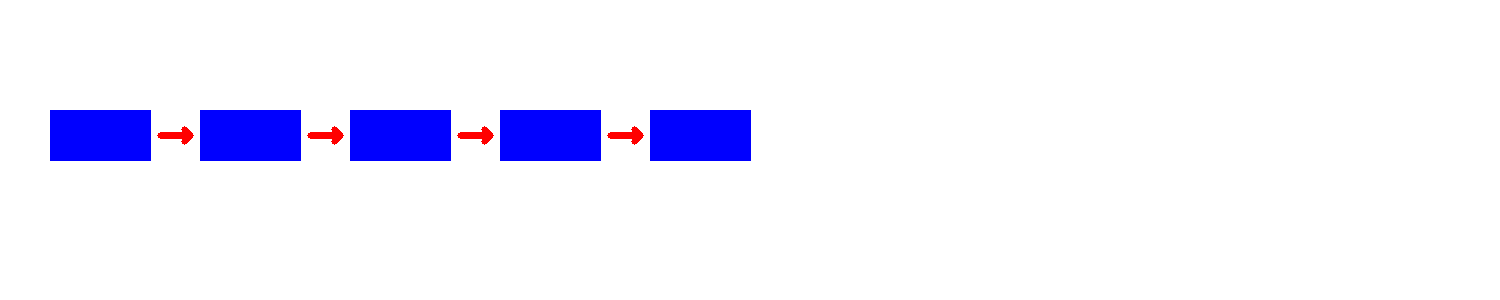

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Necessary import if we are working in Google Colab. Otherwise,
# if will use cv2.imshow(), this import is not required.
from google.colab.patches import cv2_imshow

img = np.zeros((300, 1500, 3), dtype="uint8")
img[:] = (255,255,255)
cv2.rectangle(img, (50,110), (150,160), (255,0,0), (-1))
cv2.arrowedLine(img, (160,135), (190,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,110), (300,160), (255,0,0), (-1))
cv2.arrowedLine(img, (310,135), (340,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,110), (450,160), (255,0,0), (-1))
cv2.arrowedLine(img, (460,135), (490,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (500,110), (600,160), (255,0,0), (-1))
cv2.arrowedLine(img, (610,135), (640,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,110), (750,160), (255,0,0), (-1))
cv2_imshow(img)

## 접근 방법

원가계산을 하기 위해서는 재료비, 노무비, 그리고 제조경비를 구해야 합니다. 재료비 중에 직접 재료비는 주어져 있고, 간접재료비는 예정배부율 방식으로 배부율이 정해져 있기 때문에 재료비는 쉽게 구할 수 있습니다. 직접 노무비의 경우 표준공수를 구하고 그 값에 작업자 시급을 곱해서 구할 수 있습니다. 간접 노무비의 경우 직접 노무비에 예정배부율 방식으로 배부율이 정해져 있기 때문에 직접 노무비의 값만 정해지면 큰 어려움 없이 구할 수 있습니다. 마지막으로 이 문제에서는 경비가 없는 것으로 가정 했기 때문에 고려하지 않아도 됩니다.


BOM을 보면 제품 15101008 을 만들기 위해서 25151005와 35101014, 35101015, 그리고 35101013 의 반제품이 필요하고, 해당 반제품을 만들기 위해서 소요되는 작업 시간을 계산해야 합니다. 따라서 아래와 같은 방식으로 접근해야 합니다.

1. BOM을 분석해서 필요한 반제품을 계산하는데 들어가는 시간과 반제품들을 조립해서 제품을 만드는 데 걸리는 각 공정별 평균 소요 시간을 계산합니다.

2. 각 공정별 평균 소요 시간을 바탕으로 표준공수를 구합니다.

3. 표준 공수에 작업자 시급을 곱해서 직접 노무비를 구합니다. 그리고 예정배부율을 이용해서 간접 노무비도 산출합니다.

4. BOM 기준 소요량을 바탕으로 직접 재료비를 구합니다. 그리고 예정배부율을 이용해서 간접 재료비도 산출합니다.

5. 직접재료비, 간접재료비, 집적 노무비, 그리고 간접 노무비를 합해서 새로운 제품의 BOM 기준 제조원가를 구합니다.






## 1. BOM을 분석해서 필요한 반제품을 계산하는데 들어가는 시간과 반제품들을 조립해서 제품을 만드는 데 걸리는 각 공정별 평균 소요 시간을 계산합니다.


데이터를 먼저 읽어들입니다.

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving exercise_5_basic,advanced.xlsx to exercise_5_basic,advanced.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io

df=pd.read_excel(io.BytesIO(uploaded['exercise_5_basic,advanced.xlsx']))

df

df.head()



,A Process,B Process,C Process,D Process,E Process
0,2.988561,2.049931,2.513857,1.007318,1.991486
1,2.899687,1.962657,2.587462,1.010602,2.149283
2,2.999185,1.958594,2.483914,1.017890,1.972110
3,3.022741,1.969699,2.491001,0.988635,1.990637
4,2.911437,2.027810,2.542645,0.996162,2.097959


In [ ]:
print(df.mean())


A Process    3.000569
B Process    1.999302
C Process    2.499597
D Process    0.999877
E Process    1.999705
dtype: float64


In [ ]:
print(df.var())


A Process    0.009985
B Process    0.003614
C Process    0.002511
D Process    0.000400
E Process    0.012201
dtype: float64


## 2. 각 공정별 평균 소요 시간을 바탕으로 표준공수를 구합니다.

각 공정별 평균 소요 시간을 바탕으로 품목코드별 표준공수를 구합니다.

A공정부터 순차적으로 진행되어서 E공정이 끝나면 품목코드 15101008 제품이 만들어 집니다.


In [ ]:
p1 = df.mean()

print(p1)

A Process    3.000569
B Process    1.999302
C Process    2.499597
D Process    0.999877
E Process    1.999705
dtype: float64


## 3. 표준 공수에 작업자 시급을 곱해서 직접 노무비를 구합니다. 그리고 예정배부율을 이용해서 간접 노무비도 산출합니다.


앞서 구한 공정별 평균 소요시간에 시급을 곱해서 공정별 직접 노무비를 산출합니다.



In [ ]:
## p1을 이용해서 노무비 (직접노무비 + 간접노무비)를 구합니다.
wage = 10000

overhead_rate = 0.15

direct_labor = p1 * wage

indirect_labor = direct_labor * overhead_rate

cost1 = direct_labor + indirect_labor

print(cost1)

A Process    34506.542407
B Process    22991.971994
C Process    28745.365107
D Process    11498.583712
E Process    22996.608013
dtype: float64


## 4. BOM 기준 소요량을 바탕으로 직접 재료비를 구합니다. 그리고 예정배부율을 이용해서 간접 재료비도 산출합니다.


직접 재료비는 9,800 X 2 이고, 간접재료비는 이 금액에 10%입니다.

In [ ]:
## 문제에서 주어진 BOM과 원재료의 가격을 이용해 재료비 (직접 재료비 + 간접재료비) 를 구합니다.
direct_material = 9800 * 2

indirect_material = direct_material * 0.1

material_cost = direct_material + indirect_material

print(material_cost)



21560.0


## 5. 직접재료비, 간접재료비, 집적 노무비, 그리고 간접 노무비를 합해서 새로운 제품의 BOM 기준 제조원가를 구합니다.

앞에서 구한 모든 값들을 이용해서 제조원가를 계산합니다.




In [ ]:
## 제조원가 pcost1 을 구합니다.
pcost1 = material_cost + indirect_material + direct_labor + indirect_labor

print(pcost1)


A Process    58026.542407
B Process    46511.971994
C Process    52265.365107
D Process    35018.583712
E Process    46516.608013
dtype: float64


# 최종과제 (심화)

## 접근 방법

이번 문제는 이미 양산 중인 제품의 일부 공정을 외주로 돌리는 것에 대해서 얼마나 우리에게 이득일지 혹은 손실일지를 판단하기 위해 특정 반제품의 원가를 산출하고 이를 외주비와 비교하는 방법을 알아보는 문제입니다. 이전 과정에서 산출한 값들을 이용해서 간단하게 풀어보도록 하겠습니다.

1. 앞의 문제에서 구한 공정별 제조원가를 바탕으로 반제품별 제조원가를 구한다.

2. 외주 여부를 결정한다.


In [ ]:
pcost2 = np.zeros((6,1))

## pcost2를 다음과 같이 누적의 형태로 구성합니다.
## pcost2[0] = 재료비
## pcost2[1] = 재료비 + 첫번째 공정의 노무비
## pcost2[2] = 재료비 + 두번째 공정까지의 누적 노무비
## pcost2[3] = 재료비 + 세번째 공정까지의 누적 노무비
## pcost2[4] = 재료비 + 네번째 공정까지의 누적 노무비
## pcost2[5] = 재료비 + 다섯번째 공정까지의 누적 노무비

pcost2[0] = material_cost

labor_cum = (direct_labor + indirect_labor).cumsum()

for i in range(5):
    pcost2[i+1] = material_cost + labor_cum.iloc[i]

print(pcost2)





[[ 21560.        ]
 [ 56066.54240723]
 [ 79058.51440171]
 [107803.8795089 ]
 [119302.4632207 ]
 [142299.07123361]]


In [ ]:
## 네번째 공정까지의 누적 노무비와 재료비의 합을 외주비와 비교합니다.
## 외주가 이득이면 "외주가 이득이다." 를
## 직접 제조하는 것이 이득이면 "직접 제조하는 것이 이득이다."를 출력합니다.
outsourcing_cost = 120000

if pcost2[4] > outsourcing_cost:
    print("외주가 이득이다.")
else:
    print("직접 제조하는 것이 이득이다.")

직접 제조하는 것이 이득이다.
